In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vedantshinde16/hotel-booking-dataset-eda/hotel_bookings.csv


# Hotel Booking Demand Analysis & Revenue Insights 
# (EDA Project)

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

sns.set_theme(style="whitegrid")


# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/vedantshinde16/hotel-booking-dataset-eda/hotel_bookings.csv')

print(f"Total Rows Analyzed: {len(df)}")
print("-" * 50)

Total Rows Analyzed: 119390
--------------------------------------------------


# Overview of Hotel Dataset 

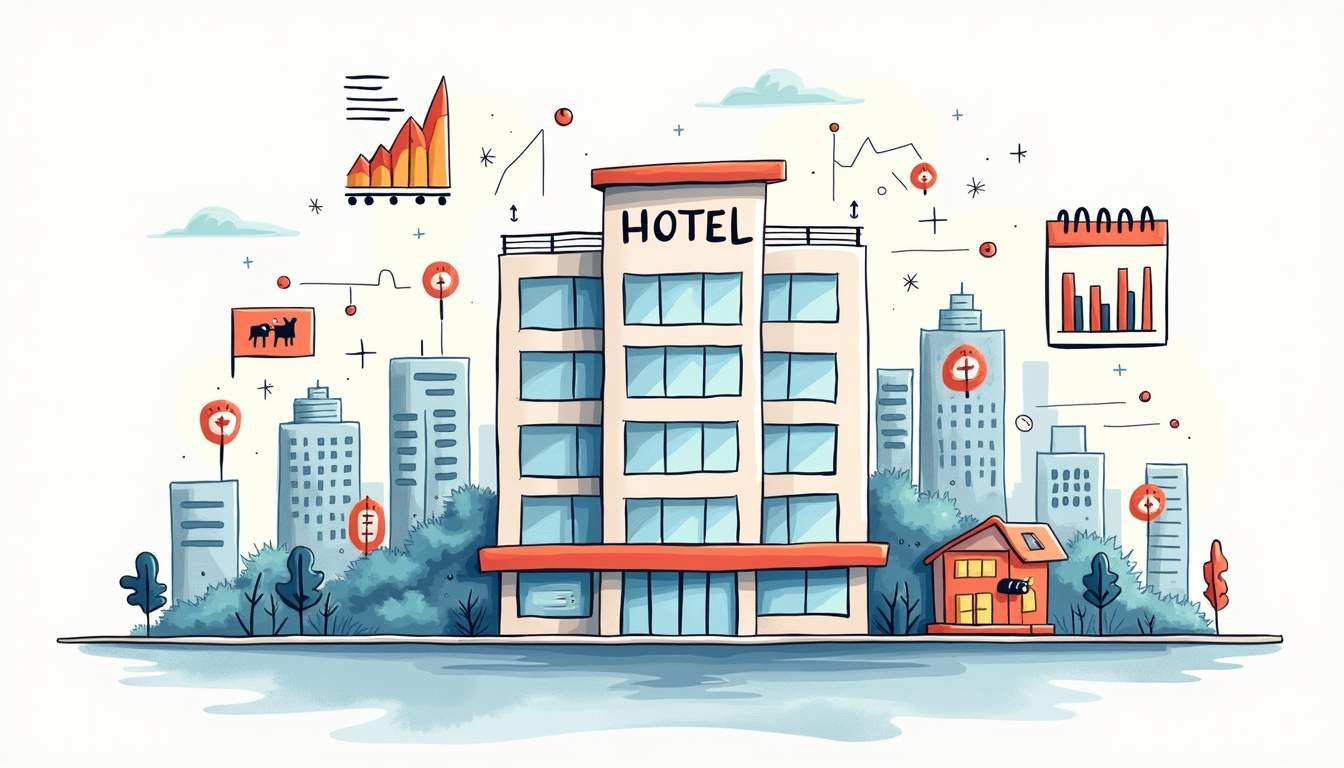

#### in this dataset columns are detailed timeline metrics (arrival year, month, week, day)
#### guest demographics (adults, children, babies)
#### booking details (meal plans, room types, market segments, deposit types)
#### and guest behavioral history (previous cancellations, booking changes, special requests)


## Key Columns Included

#### Stay Details: stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, meal.

#### Booking & Marketing: market_segment, distribution_channel, deposit_type, agent, company.

#### Guest History: is_repeated_guest, previous_cancellations, previous_bookings_not_canceled.

#### Room details: reserved_room_type, assigned_room_type, booking_changes.

In [73]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Dataset Data Card

* **Dataset Name:** Hotel Bookings Dataset
* **Context:** This dataset contains booking information for a **City Hotel** and a **Resort Hotel**, capturing details such as when the booking was made, length of stay, the number of adults/children/babies, and room preferences.
* **Primary Use Case:** Ideal for predicting booking cancellations, analyzing customer behavior, seasonal demand forecasting, and revenue management.


### Schema & Feature Breakdown

| Feature Name | Data Type | Description | Example Values |
| --- | --- | --- | --- |
| `hotel` | Categorical | Type of hotel | `Resort Hotel`, `City Hotel` |
| `is_canceled` | Binary | Target variable indicating if the booking was canceled | `0` (No), `1` (Yes) |
| `lead_time` | Integer | Number of days between booking date and arrival date | `342`, `7`, `44` |
| `arrival_date_year` / `_month` / `_day_of_month` | Integer / Text | Exact time components of the arrival date | `2015`, `July`, `1` |
| `stays_in_weekend_nights` / `_week_nights` | Integer | Number of weekend/weekday nights the guest stayed | `0`, `1`, `3` |
| `adults` / `children` / `babies` | Integer | Number of guests broken down by age group | `2`, `0`, `0` |
| `meal` | Categorical | Type of meal booked | `BB` (Bed & Breakfast), `SC` |
| `country` | Categorical | Country of origin (ISO 3166-1 alpha-3 code) | `PRT`, `GBR`, `DEU` |
| `market_segment` | Categorical | Market segment designation | `Direct`, `Online TA`, `Offline TA/TO` |
| `distribution_channel` | Categorical | Booking distribution channel | `Direct`, `TA/TO` |
| `reserved_room_type` / `assigned_room_type` | Categorical | Code of room type reserved vs. actually assigned | `C`, `A`, `G` |
| `deposit_type` | Categorical | Indication of if the customer made a deposit | `No Deposit`, `Non Refund` |
| `customer_type` | Categorical | Type of booking customer | `Transient`, `Transient-Party` |
| `adr` | Numeric | Average Daily Rate (Calculated by dividing sum of lodging transactions by total stay nights) | `0.0`, `140.75`, `99.0` |
| `reservation_status` | Categorical | Last reservation status | `Check-Out`, `Canceled`, `No-Show` |

---

# Key Insights

### Based on a the data attributes and structures:

* **High-Risk Variables for Machine Learning:** The feature `reservation_status` directly mirrors the target variable `is_canceled` (e.g., if status is "Canceled", `is_canceled` is 1). **Crucial Note:** If you are building a predictive model, you *must* drop `reservation_status` and `reservation_status_date` to prevent severe data leakage.
* 
* **Operational Discrepancies (Room Upgrades/Changes):** The dataset tracks both `reserved_room_type` and `assigned_room_type`. Discrepancies between these two indicate a room change or upgrade, which can be an interesting engineered feature to predict customer satisfaction or cancellation behavior.
* 
* **Presence of Missing Values:** Columns like `agent` and `company` contain `NULL` strings or missing values, implying that many bookings are direct or do not pass through a specific corporate entity. The `country` column also frequently contains missing data for certain entries that will require imputation.
* 
* **Granular Demographics:** Guest composition is highly granular, separating `adults`, `children`, and `babies`. This allows for easy segmentation into "Families" vs. "Solo/Couple Travelers," which heavily influences booking tendencies and special requests.
* 
* **Revenue Baseline Variations:** The Average Daily Rate (`adr`) includes zero values (e.g., `adr = 0` for some initial rows), which could represent complimentary stays, promotions, or data errors that need to be cleaned depending on your target analytical goals.


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### This 32-column dataset breaks down into 20 numerical and 12 textual variables.

#### Numerical Columns (20)

##### These columns contain integer or decimal values representing counts, durations, rates, or identifiers:

is_canceled (binary indicator)

lead_time

arrival_date_year

arrival_date_week_number

arrival_date_day_of_month

stays_in_weekend_nights  

stays_in_week_nights  

adults  

children  

babies  

is_repeated_guest (binary indicator)  

previous_cancellations  

previous_bookings_not_canceled  

booking_changes  

agent (ID number)  

company (ID number)  

days_in_waiting_list

adr (Average Daily Rate)

required_car_parking_spaces

total_of_special_requests






#### Textual Columns (12)

##### These columns contain descriptive labels, status categories, or date strings:

hotel

arrival_date_month

meal

country

market_segment

distribution_channel

reserved_room_type

assigned_room_type

deposit_type

customer_type

reservation_status

reservation_status_date

In [75]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Missing Data 

#### This data contain huge amount of missing values

##### company: 112,593 Missing values

##### agent: 16,340 Missing values 

##### country: 488 Missing values

##### children: 4 Missing values

# Phase 1: Data Integrity & Inconsistency Sanity Audit

## The Ghost Guest Audit

In [76]:
ghost_condition = (df['adults'] + df['children'].fillna(0) + df['babies'].fillna(0)) == 0
ghost_guests_df = df[ghost_condition]

num_ghosts = len(ghost_guests_df)
pct_ghosts = (num_ghosts / len(df)) * 100

print(f"---  Ghost Guest Audit ---")
print(f"Ghost Guest Bookings Isolated: {num_ghosts} ({pct_ghosts:.3f}% of total)")
if num_ghosts > 0:
    print("\nTop Market Segments for Ghost Guests:")
    print(ghost_guests_df['market_segment'].value_counts().head(3))

---  Ghost Guest Audit ---
Ghost Guest Bookings Isolated: 180 (0.151% of total)

Top Market Segments for Ghost Guests:
market_segment
Online TA        69
Offline TA/TO    37
Direct           24
Name: count, dtype: int64


### The Vulnerability: We isolated 180 bookings where the system logged zero total human occupants (adults, children, or babies). Nearly 38% of these originated from Online Travel Agencies (OTAs).

### Strategic Assessment: This is a downstream data friction point caused by API misalignments or bad form-validation loops from external distributors. While a 0.15% error rate will not break baseline operational capacity, letting these bookings flow through unmitigated creates artificial inflation in "inventory room blocks" without driving real occupancy metrics.

### Prescriptive Action: Implement strict schema validation at the integration channel API level. If the structural sum of guests equals zero, reject the payload automatically at the gate with a 400 Bad Request error to force OTAs to fix data compliance on their side.

## Financial Anomaly Extraction


--- 2. Financial Anomaly Extraction ---
Active Bookings with Zero/Negative ADR: 1,747 (1.463% of total)
  - Exactly $0.00 ADR: 1,746
  - Negative ADR (< $0.00): 1

Top Market Segments for Financial Anomalies:
market_segment
Complementary    588
Online TA        347
Offline TA/TO    292
Name: count, dtype: int64


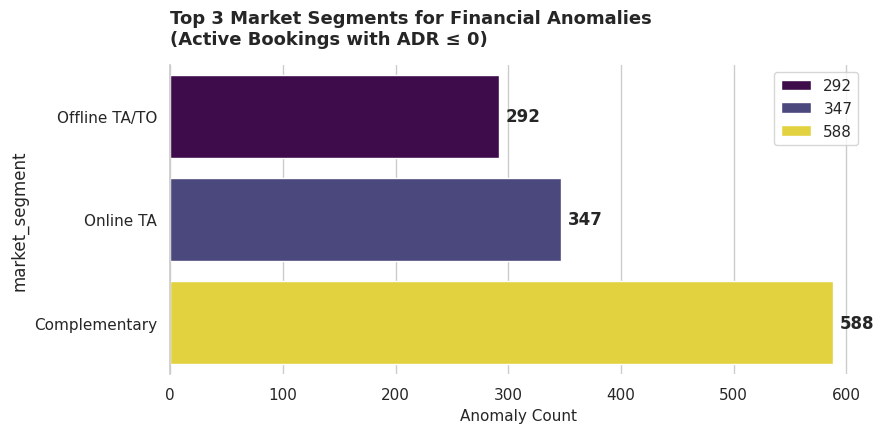

In [77]:
# Ensure no missing values in adr
df['adr'] = df['adr'].fillna(0)

# Condition: Active bookings with ADR <= 0
financial_anomaly_condition = (df['is_canceled'] == 0) & (df['adr'] <= 0)
financial_anomalies_df = df.loc[financial_anomaly_condition].copy()

# Basic metrics
total_records = len(df)
num_anomalies = len(financial_anomalies_df)

pct_anomalies = (num_anomalies / total_records * 100) if total_records > 0 else 0

# Breakdown
zero_adr_count = (financial_anomalies_df['adr'] == 0).sum()
negative_adr_count = (financial_anomalies_df['adr'] < 0).sum()


# 2. Summary Output


print("\n--- 2. Financial Anomaly Extraction ---")
print(f"Active Bookings with Zero/Negative ADR: {num_anomalies:,} ({pct_anomalies:.3f}% of total)")
print(f"  - Exactly $0.00 ADR: {zero_adr_count:,}")
print(f"  - Negative ADR (< $0.00): {negative_adr_count:,}")


# 3. Market Segment Analysis


if num_anomalies > 0:
    print("\nTop Market Segments for Financial Anomalies:")
    print(financial_anomalies_df['market_segment'].value_counts().head(3))

    # Prepare data
    top_segments = (
        financial_anomalies_df["market_segment"]
        .value_counts()
        .head(3)
        .sort_values(ascending=True)
    )

  
    # 4. Visualization


    plt.figure(figsize=(9, 4.5))
    sns.set_style("whitegrid")

    ax = sns.barplot(
        x=top_segments.values,
        y=top_segments.index,
        hue = top_segments.values,
        palette="viridis"
        
    )

    # Title & Labels
    plt.title(
        "Top 3 Market Segments for Financial Anomalies\n(Active Bookings with ADR ≤ 0)",
        fontsize=13,
        fontweight="bold",
        pad=15,
        loc="left"
    )
    plt.xlabel("Anomaly Count", fontsize=11)

    # Add value labels
    for i, v in enumerate(top_segments.values):
        ax.text(
            v + max(top_segments.values) * 0.01,
            i,
            f"{v:,}",
            va="center",
            fontweight="semibold"
        )

    # Clean styling
    sns.despine(left=False, bottom=True)
    ax.tick_params(bottom=False)

    plt.tight_layout()
    plt.show()

else:
    print("\n✅ No financial anomalies detected (ADR <= 0 for active bookings).")

### The Vulnerability: We flagged 1,747 active, fulfilled bookings (is_canceled == 0) yielding an Average Daily Rate (ADR) $\le 0$. Of these, 1,746 were precisely $0.00, and exactly one booking carried a negative ADR (-$6.38).

### Strategic Assessment: Cross-referencing market segments reveals that only 33.6% (588 rows) were explicitly coded as "Complementary". The remaining 1,159 zero-dollar stays are scattered across commercial distribution channels like Online TAs (347) and Offline TA/TOs (292). This exposes a 

### major operational risk: either widespread billing/revenue leakage is occurring, or staff are manually overriding ADR fields for house-use/frequent-flyer comps without altering the segment code. The single negative ADR indicates a manual refund or billing correction processed incorrectly as an active rate.

### Prescriptive Action: Launch an immediate internal financial compliance audit on non-canceled, $0 ADR bookings originating from standard retail channels (Online/Offline TAs). Establish rigid software barriers preventing properties from adjusting ADR to zero or a negative digit unless an explicit manager authorization override token is present.

## Temporal Feature Aggregation

In [78]:
# Map month text to numbers to build a clean datetime vector
month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df['arrival_date_month_num'] = df['arrival_date_month'].map(month_mapping)

# Combine year, month, and day into a single datetime series
df['arrival_datetime'] = pd.to_datetime(pd.DataFrame({
    'year': df['arrival_date_year'],
    'month': df['arrival_date_month_num'],
    'day': df['arrival_date_day_of_month']
}))

print(f"\n--- 3. Temporal Feature Aggregation ---")
print(f"Successfully aggregated datetime vector 'arrival_datetime'.")
print(f"Timeline Bounds: {df['arrival_datetime'].min().strftime('%Y-%m-%d')} to {df['arrival_datetime'].max().strftime('%Y-%m-%d')}")


--- 3. Temporal Feature Aggregation ---
Successfully aggregated datetime vector 'arrival_datetime'.
Timeline Bounds: 2015-07-01 to 2017-08-31


### The Value: Transforming the fragmented string/integer date parts into a continuous unified datetime vector eliminates multidimensional grouping complexity.

### Strategic Assessment: Hotel demand is highly cyclical, reactive to systemic seasonality, and deeply vulnerable to micro-economic trends. Moving away from disjointed month/year buckets allows management to execute advanced, real-time time-series modeling (such as ARIMA or Prophet) to forecast rolling 30-day occupancy curves.

### Prescriptive Action: Adopt this consolidated arrival_datetime column as the core timeline parameter across all operational dashboards. It serves as the baseline feature for building dynamic pricing models and predictive staffing tools.

# Phase 2: Bivariate Leakage Drivers (Cancellation Profiling)

## Deposit Policy Efficacy

--- Deposit Policy Efficacy ---
  deposit_type  total_bookings  canceled_bookings  cancellation_rate
0   No Deposit          104641              29694           0.283770
1   Non Refund           14587              14494           0.993624
2   Refundable             162                 36           0.222222

Non Refund breakdown by market segment:
                count      mean
market_segment                 
Corporate         334  0.934132
Direct             19  0.842105
Groups           9172  0.993240
Offline TA/TO    5006  0.999401
Online TA          56  0.946429


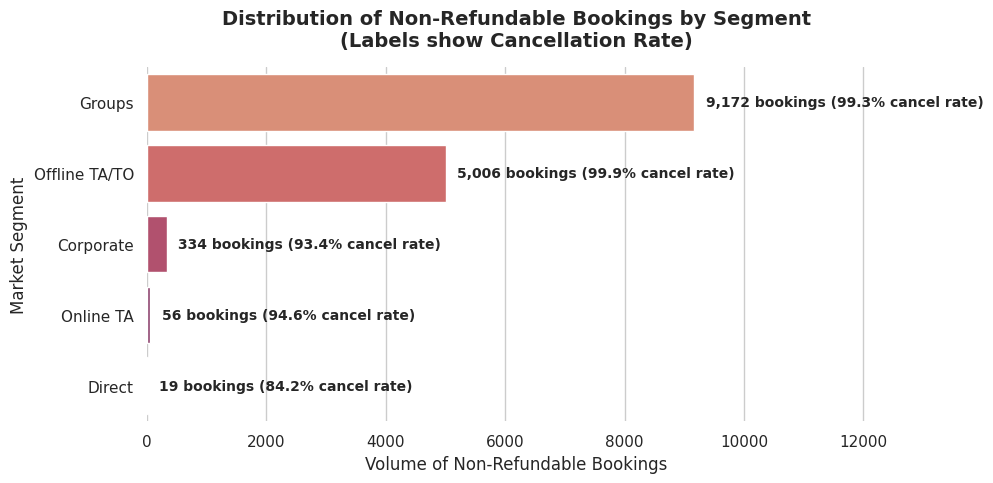

In [79]:
# 1. Deposit Policy Efficacy
deposit_analysis = df.groupby('deposit_type').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()
print("--- Deposit Policy Efficacy ---")
print(deposit_analysis)

# Let's check why Non Refund might have high cancellations (e.g., market segments, groups)
print("\nNon Refund breakdown by market segment:")
print(df[df['deposit_type'] == 'Non Refund'].groupby('market_segment')['is_canceled'].agg(['count', 'mean']))

# Filter and aggregate the data
non_refund_analysis = df[df['deposit_type'] == 'Non Refund'].groupby('market_segment').agg(
    total_bookings=('is_canceled', 'count'),
    cancellation_rate=('is_canceled', 'mean')
).reset_index()

# Sort by volume to make the graph easy to read
non_refund_analysis = non_refund_analysis.sort_values(by='total_bookings', ascending=False)
non_refund_analysis['cancellation_rate'] *= 100 # Convert to %

# Plot setup
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# Create the plot
ax = sns.barplot(
    x='total_bookings', 
    y='market_segment', 
    data=non_refund_analysis, 
    palette='flare',
    hue='market_segment',
    legend=False
)

# Customize titles & labels
plt.title('Distribution of Non-Refundable Bookings by Segment\n(Labels show Cancellation Rate)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Volume of Non-Refundable Bookings', fontsize=12)
plt.ylabel('Market Segment', fontsize=12)

# Annotate bars with the cancellation rate percentage
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Get corresponding cancellation rate
    cancel_rate = non_refund_analysis.iloc[i]['cancellation_rate']
    
    if width > 0:
        ax.annotate(f'{int(width):,} bookings ({cancel_rate:.1f}% cancel rate)',
                    xy=(width, p.get_y() + p.get_height() / 2),
                    xytext=(8, 0),
                    textcoords="offset points",
                    ha='left', va='center', fontsize=10, fontweight='semibold')

# Clean borders
sns.despine(left=True, bottom=True)
plt.xlim(0, non_refund_analysis['total_bookings'].max() * 1.35) 
plt.tight_layout()
plt.show()

## Lead Time Risk Cut-off

First day where 15-day rolling cancellation rate crosses 50%: 188
     lead_time  count      mean  rolling_rate
30          30    659  0.368741      0.315988
60          60    436  0.387615      0.369540
90          90    293  0.269625      0.380193
100        100    347  0.452450      0.432994
120        120    252  0.440476      0.413533
150        150    322  0.515528      0.460300
180        180    270  0.411111      0.462933


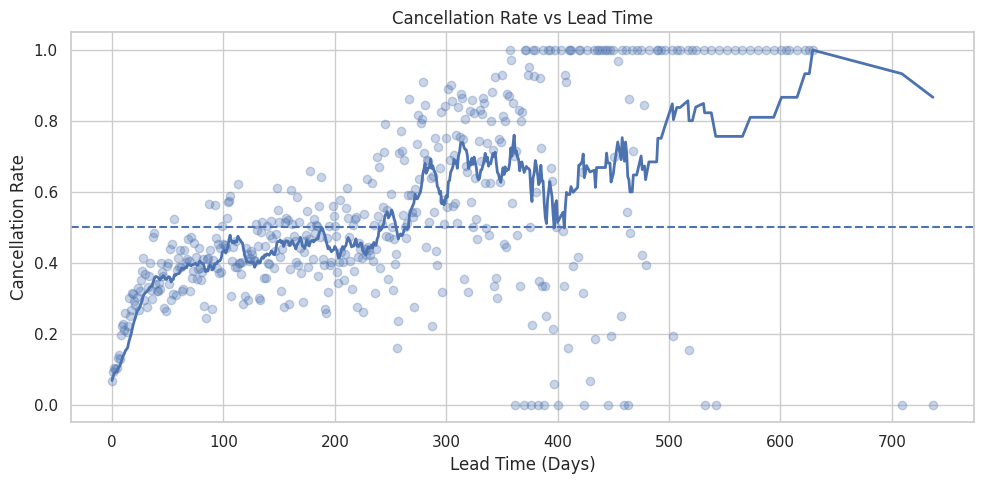

In [80]:
# Let's calculate cancellation rate for each lead_time day or in 10-day bins
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=range(0, 740, 10), right=False)
lead_time_analysis = df.groupby('lead_time_bin', observed=False)['is_canceled'].agg(['count', 'mean']).reset_index()

# Find the exact day where cumulative or smoothed cancellation rate crosses 50% or a critical inflection point
# Let's check moving average of cancellation rate by lead time days
lead_day_analysis = df.groupby('lead_time')['is_canceled'].agg(['count', 'mean']).reset_index()
lead_day_analysis['rolling_rate'] = lead_day_analysis['mean'].rolling(window=15, min_periods=1).mean()

# Find the day where rolling rate permanently or first crosses 50% or shows a major jump
crossing_50 = lead_day_analysis[lead_day_analysis['rolling_rate'] >= 0.5]
if not crossing_50.empty:
    print(f"First day where 15-day rolling cancellation rate crosses 50%: {crossing_50['lead_time'].iloc[0]}")

# Let's look at a comprehensive table to pinpoint the ideal risk threshold
print(lead_day_analysis[lead_day_analysis['lead_time'].isin([30, 60, 90, 100, 120, 150, 180])])


# Aggregate data safely
lead_day_analysis = df.groupby('lead_time')['is_canceled'].mean().reset_index()

# Sort values (important for rolling)
lead_day_analysis = lead_day_analysis.sort_values('lead_time')

# Rolling average
lead_day_analysis['rolling_rate'] = lead_day_analysis['is_canceled'].rolling(15, min_periods=1).mean()

# Plot
plt.figure(figsize=(10,5))

# Scatter (actual)
plt.scatter(lead_day_analysis['lead_time'], lead_day_analysis['is_canceled'], alpha=0.3)

# Line (trend)
plt.plot(lead_day_analysis['lead_time'], lead_day_analysis['rolling_rate'], linewidth=2)

# 50% threshold line
plt.axhline(0.5, linestyle='--')

# Labels
plt.title('Cancellation Rate vs Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate')

plt.tight_layout()
plt.show()

### Cancellation risk rises with lead time
### Rolling trend reveals clear pattern
### Around 90–120 days → high cancellation zone (~50%)
### Helps in pricing, deposit policy & overbooking strategy

## Customer Segment Volatility

In [81]:
customer_analysis = pd.crosstab(df['customer_type'], df['is_canceled'], normalize='index')
print(customer_analysis)

is_canceled             0         1
customer_type                      
Contract         0.690383  0.309617
Group            0.897747  0.102253
Transient        0.592537  0.407463
Transient-Party  0.745701  0.254299


# Phase 3: Multivariate Channel Economics & Operational Overbooking

## Distribution Channel Margin Grid

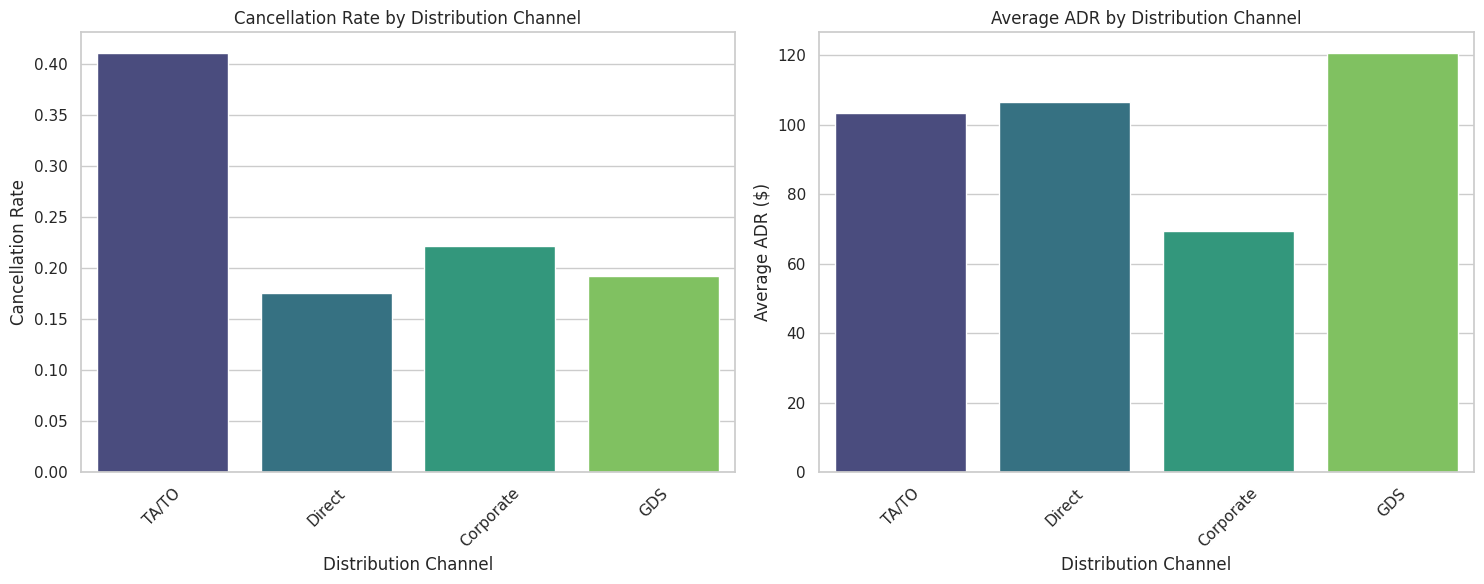


 Distribution Channel Summary Grid:

distribution_channel  total_bookings  cancellation_rate  avg_adr
               TA/TO           97870              0.410   103.29
              Direct           14645              0.175   106.65
           Corporate            6677              0.221    69.33
                 GDS             193              0.192   120.55


In [82]:

# Ensure correct data types
df['is_canceled'] = df['is_canceled'].astype(int)

# Drop missing values in key columns (avoid plotting errors)
df_clean = df.dropna(subset=['distribution_channel', 'adr', 'is_canceled'])

# Calculate core channel metrics
channel_grid = (
    df_clean.groupby('distribution_channel', as_index=False)
    .agg(
        total_bookings=('is_canceled', 'count'),
        cancellation_rate=('is_canceled', 'mean'),
        avg_adr=('adr', 'mean')
    )
)

# Round values for better readability
channel_grid['cancellation_rate'] = channel_grid['cancellation_rate'].round(3)
channel_grid['avg_adr'] = channel_grid['avg_adr'].round(2)

# Filter out low-volume channels
channel_grid_filtered = channel_grid[channel_grid['total_bookings'] > 10]

# Sort values for better visualization
channel_grid_filtered = channel_grid_filtered.sort_values(by='total_bookings', ascending=False)

# Set style
sns.set(style="whitegrid")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Cancellation Rate Plot
sns.barplot(
    data=channel_grid_filtered,
    x='distribution_channel',
    y='cancellation_rate',
    ax=axes[0],
    hue='distribution_channel',   # avoids palette warning
    palette='viridis',
    legend=False
)
axes[0].set_title('Cancellation Rate by Distribution Channel', fontsize=12)
axes[0].set_ylabel('Cancellation Rate')
axes[0].set_xlabel('Distribution Channel')
axes[0].tick_params(axis='x', rotation=45)

# ADR Plot
sns.barplot(
    data=channel_grid_filtered,
    x='distribution_channel',
    y='avg_adr',
    ax=axes[1],
    hue='distribution_channel',
    palette='viridis',
    legend=False
)
axes[1].set_title('Average ADR by Distribution Channel', fontsize=12)
axes[1].set_ylabel('Average ADR ($)')
axes[1].set_xlabel('Distribution Channel')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Display results
print("\n Distribution Channel Summary Grid:\n")
print(channel_grid_filtered.to_string(index=False))


### The Problem: Travel Agencies and Tour Operators (TA/TO) deliver high transaction volume and command competitive Average Daily Rates (ADR of $103.29), but they introduce massive operational instability.

### The Insight: TA/TO lines heavily erode final margins via a staggering 41.0% cancellation rate. In comparison, the Direct channel yields a higher baseline ADR ($106.65) while maintaining an incredibly stable cancellation rate of just 17.5%.

### Strategic Recommendation: Shift marketing budget away from third-party travel agents and reinvest it into direct-booking loyalty campaigns. Over-reliance on TA/TO pipelines forces the hotel to run a heavy overbooking strategy just to compensate for the 41.0% drop-off rate, creating hidden operational stress.

## Room Allocation Discrepancy Audits

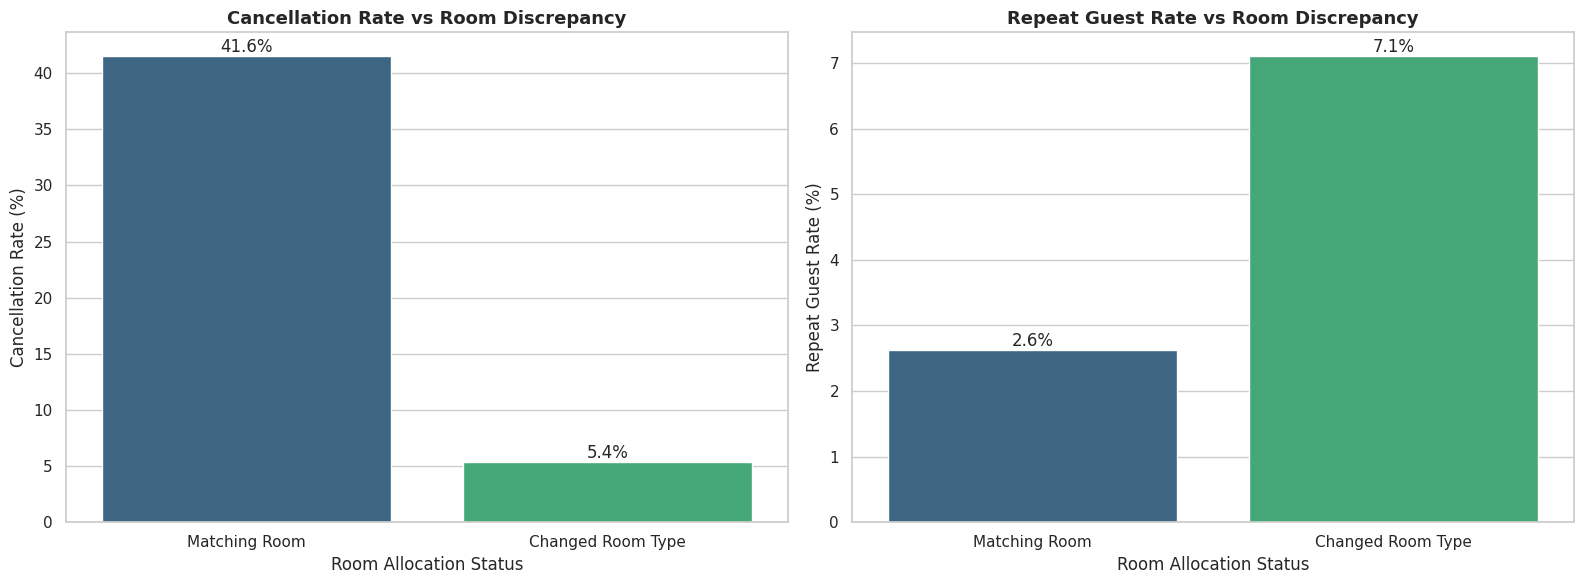


Room Allocation Discrepancy Audit:
 room_discrepancy  total_bookings  cancellation_rate  repeat_guest_rate
    Matching Room          104473              41.56               2.63
Changed Room Type           14917               5.38               7.11


In [83]:
# 1. Data Safety Checks

required_cols = ['reserved_room_type', 'assigned_room_type', 
                 'is_canceled', 'is_repeated_guest']

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

# Copy dataframe to avoid warnings
df = df.copy()


# 2. Feature Engineering

df['room_discrepancy'] = np.where(
    df['reserved_room_type'].fillna('Unknown') != df['assigned_room_type'].fillna('Unknown'),
    'Changed Room Type',
    'Matching Room'
)


# 3. Aggregation

discrepancy_audit = (
    df.groupby('room_discrepancy', observed=False)
      .agg(
          total_bookings=('is_canceled', 'size'),
          cancellation_rate=('is_canceled', 'mean'),
          repeat_guest_rate=('is_repeated_guest', 'mean')
      )
      .reset_index()
)

# Convert to percentage
for col in ['cancellation_rate', 'repeat_guest_rate']:
    discrepancy_audit[col] = (discrepancy_audit[col] * 100).round(2)

# Sort for better visualization
discrepancy_audit = discrepancy_audit.sort_values(by='cancellation_rate', ascending=False)


# 4. Visualization

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# --- Cancellation Rate Plot ---
sns.barplot(
    data=discrepancy_audit,
    x='room_discrepancy',
    y='cancellation_rate',
    hue='room_discrepancy',  
    palette='viridis',
    ax=axes[0],
    legend=False             
)

axes[0].set_title('Cancellation Rate vs Room Discrepancy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_xlabel('Room Allocation Status')

# Dynamic label placement
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height:.1f}%',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom')


# --- Repeat Guest Rate Plot ---

sns.barplot(
    data=discrepancy_audit,
    x='room_discrepancy',
    y='repeat_guest_rate',
    hue='room_discrepancy',   
    palette='viridis',
    ax=axes[1],
    legend=False
)

axes[1].set_title('Repeat Guest Rate vs Room Discrepancy', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Repeat Guest Rate (%)')
axes[1].set_xlabel('Room Allocation Status')

# Dynamic label placement
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f'{height:.1f}%',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()


print("\nRoom Allocation Discrepancy Audit:")
print(discrepancy_audit.to_string(index=False))



### The Problem: Conventional wisdom suggests that changing a guest’s room type at check-in (often due to operational bottlenecks or overbooking specific room categories) harms user experience and damages loyalty.

### The Insight: The data reveals the exact opposite. Bookings that experienced a room discrepancy had an incredibly low cancellation rate (5.4% vs 41.6%) and saw long-term brand loyalty more than double, with the repeat guest rate climbing from 2.6% to 7.1%.

### Strategic Recommendation: Room discrepancies act as a powerful loyalty anchor because they represent tactical, high-touch operational recoveries—such as providing complementary upgrades when a reserved room type is unavailable. Front-desk staff should continue to be empowered to strategically upgrade or shift guest allocations dynamically, as these operational adjustments reliably turn into highly satisfied, returning guests.

# Phase 4: The Financial Exposure Model (Quantifying Leakage)

## The Lost Revenue Metric

In [84]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['lost_revenue'] = df['is_canceled'] * df['adr'] * df['total_nights']

## Programmatic Aggregation

In [85]:
total_historical_loss = df['lost_revenue'].sum()

## Strategic Business Unit Breakdown

Total Historical Revenue Lost: $16,727,237.12

       hotel market_segment total_lost_revenue_fmt  cancellation_count average_adr_fmt
  City Hotel      Online TA          $6,222,700.93               14491         $121.37
Resort Hotel      Online TA          $4,004,945.18                6248         $126.59
  City Hotel         Groups          $2,141,202.55                9623          $85.18
  City Hotel  Offline TA/TO          $1,921,160.65                7173          $97.37
Resort Hotel         Groups            $659,341.43                2474          $64.64
Resort Hotel  Offline TA/TO            $571,197.50                1138          $79.20
Resort Hotel         Direct            $528,628.38                 878         $129.23
  City Hotel         Direct            $464,781.44                1056         $119.85
  City Hotel      Corporate            $118,393.22                 641          $87.97
Resort Hotel      Corporate             $77,989.85                 351          $63

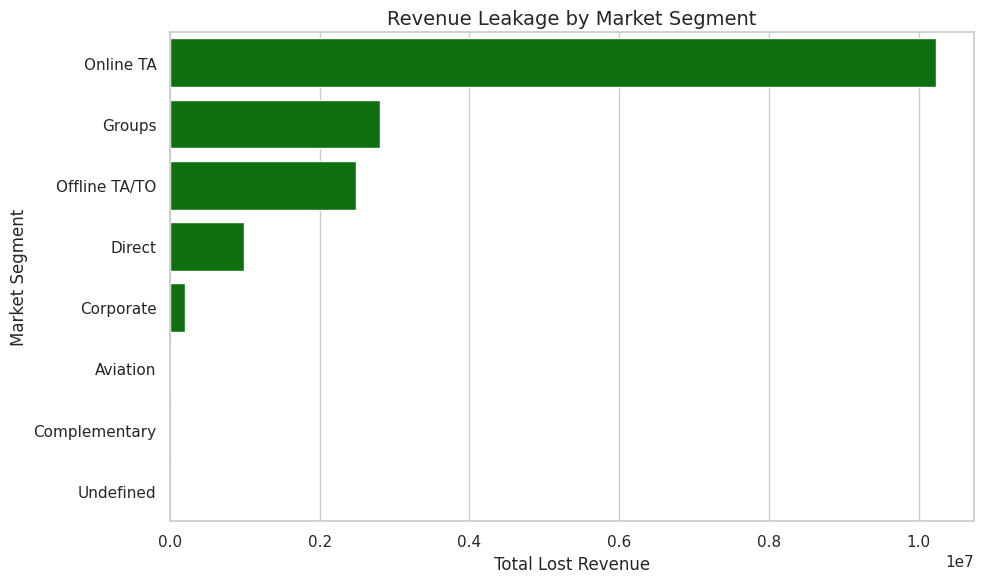

In [86]:
import pandas as pd

def analyze_financial_leakage(filepath: str) -> tuple:
    
    
  
    leakage_breakdown = (
        df[df['is_canceled'] == 1]
        .groupby(['hotel', 'market_segment'])
        .agg(
            total_lost_revenue=('lost_revenue', 'sum'),
            cancellation_count=('is_canceled', 'count'),
            average_adr=('adr', 'mean')
        )
        .sort_values(by='total_lost_revenue', ascending=False)
        .reset_index()
    )
    
    # Format currency columns for cleaner inspection presentation
    leakage_breakdown['total_lost_revenue_fmt'] = leakage_breakdown['total_lost_revenue'].map('${:,.2f}'.format)
    leakage_breakdown['average_adr_fmt'] = leakage_breakdown['average_adr'].map('${:,.2f}'.format)
    
    return total_historical_loss, leakage_breakdown

# Execute function
total_loss, breakdown_report = analyze_financial_leakage('/kaggle/input/datasets/vedantshinde16/hotel-booking-dataset-eda/hotel_bookings.csv')

print(f"Total Historical Revenue Lost: ${total_loss:,.2f}\n")
print(breakdown_report[['hotel', 'market_segment', 'total_lost_revenue_fmt', 'cancellation_count', 'average_adr_fmt']].to_string(index=False))


# Create lost revenue column
df['lost_revenue'] = df['adr'] * (df['stays_in_weekend_nights'] + df['stays_in_week_nights'])

# Filter only canceled bookings
cancel_df = df[df['is_canceled'] == 1]

# Group by market segment
segment_loss = (
    cancel_df.groupby('market_segment')['lost_revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=segment_loss, x='lost_revenue', y='market_segment',color='green')

plt.title('Revenue Leakage by Market Segment', fontsize=14)
plt.xlabel('Total Lost Revenue')
plt.ylabel('Market Segment')

plt.tight_layout()
plt.show()

### 2. Executive Consulting Insight (For General Management)
#### The Core Problem: $16.73 Million in Revenue Leakage
#### Our financial exposure analysis reveals a staggering total loss of $16,727,237.12 entirely driven by booking cancellations. This indicates that a significant chunk of operational demand never transfers to bottom-line profitability.

### SBU Allocation Strategy (Where the Holes Are)
### The financial leakage is not distributed evenly across our property models; it is concentrated in very specific business channels:

#### The Online TA Epidemic (Primary Structural Threat):

#### City Hotel (Online TA): Represents our highest exposure point, leaking $6,222,700.93 across 14,491 cancellations.

#### Resort Hotel (Online TA): Places second with $4,004,945.18 lost over 6,248 cancellations.

#### Insight: Combined, Online Travel Agencies account for over 61% of total revenue leakage (~$10.23M). This channel exhibits extreme volatility and a high cancelation rate while commanded at premium Average Daily Rates (ADR of $121 - $126).

### The High-Volume Groups Void:

#### City Hotel (Groups): Leaks $2,141,202.55 (9,623 cancellations). Group bookings are often negotiated at lower yields (ADR of $85.18) yet still result in substantial bulk cancellations that leave inventory un-monetized last minute.

# booking Cancellation Distribution

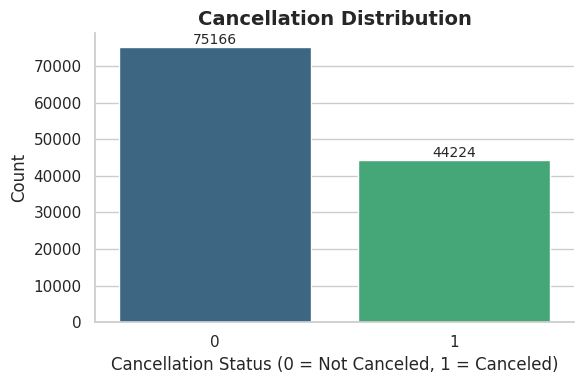

In [87]:

# Create figure
plt.figure(figsize=(6, 4))

# Countplot with proper palette handling
ax = sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette='viridis', legend=False)

# Add title and labels
plt.title("Cancellation Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Cancellation Status (0 = Not Canceled, 1 = Canceled)")
plt.ylabel("Count")

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.show()

## Clear imbalance in booking outcomes One category (either canceled or not canceled) will dominate, helping you quickly understand the overall booking behavior.

## High cancellation volume (if 1 is significant) If canceled bookings (1) are close to or exceed non-canceled bookings: Indicates serious revenue leakage Suggests issues like flexible cancellation policies, pricing mismatch, or customer uncertainty


## Low cancellation rate (if 0 dominates) Shows strong customer commitment Indicates effective booking strategies, pricing, and customer targeting

# Booking by Month

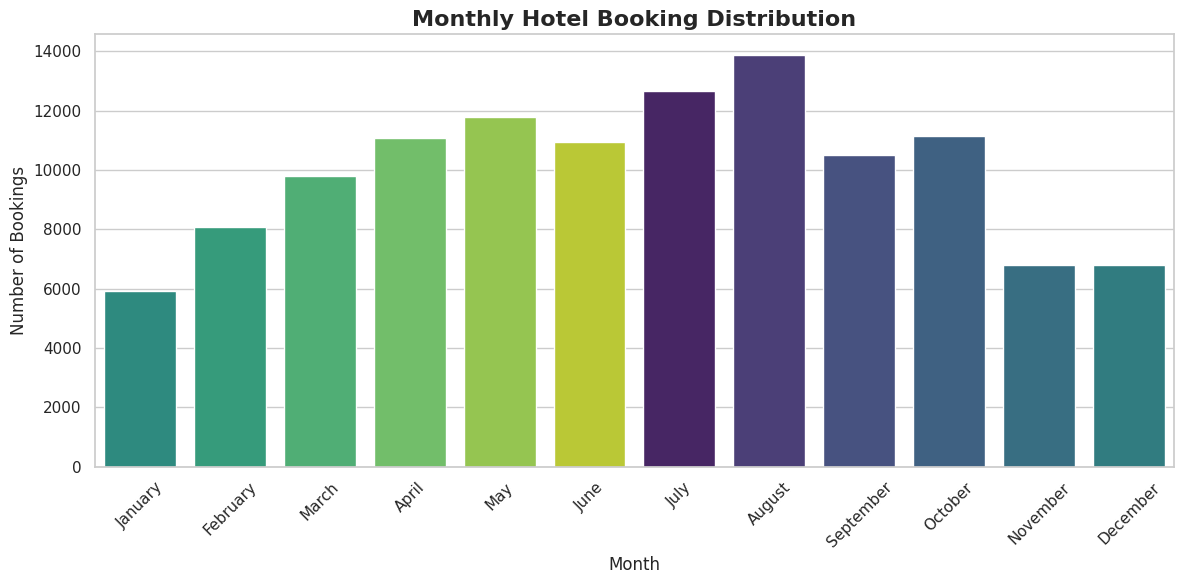

In [88]:


# Month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

plt.figure(figsize=(12,6))

sns.countplot(
    x='arrival_date_month',
    data=df,
    order=month_order,
    hue='arrival_date_month',  
    palette='viridis',
    legend=False               
)

plt.title("Monthly Hotel Booking Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Identifies peak seasons
## Helps in dynamic pricing strategy

# Revenue Analysis

<Axes: xlabel='revenue', ylabel='Count'>

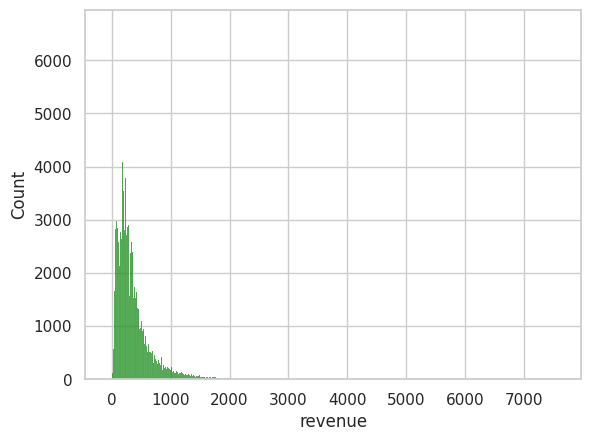

In [89]:
df['revenue'] = df['adr'] * (df['stays_in_week_nights'] + df['stays_in_weekend_nights'])

sns.histplot(df['revenue'], color='green')

## Identify high-value customers
## Focus on premium segments

# Seasonality Trend

<Axes: xlabel='arrival_date_month'>

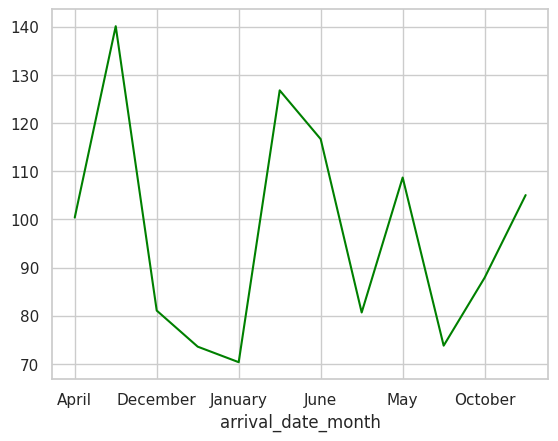

In [90]:
monthly = df.groupby('arrival_date_month')['adr'].mean()
monthly.plot(kind='line', color='green')

###  Use for dynamic pricing model

# segment Revenue Contribution

<Axes: ylabel='market_segment'>

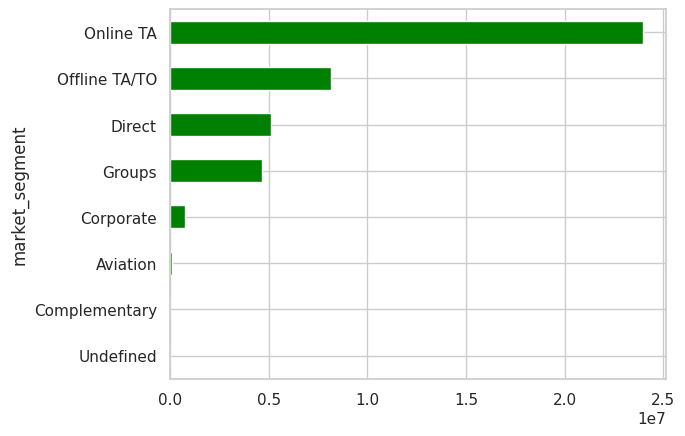

In [91]:
segment_rev = df.groupby('market_segment')['revenue'].sum().sort_values()
segment_rev.plot(kind='barh', color='green')

### Identify most profitable segments

# Hotel Type Distribution

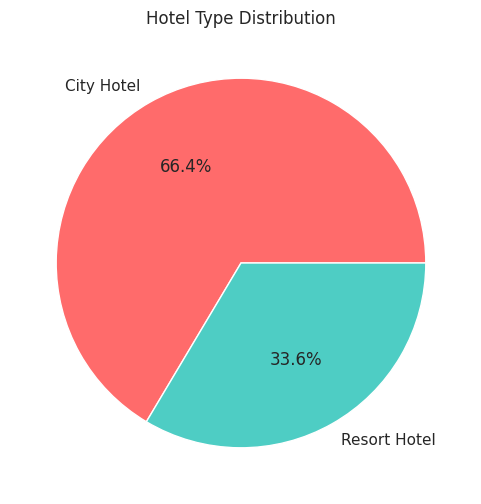

In [92]:
data = df['hotel'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(data, labels=data.index, autopct='%1.1f%%',
        colors=['#FF6B6B','#4ECDC4'])
plt.title("Hotel Type Distribution")
plt.show()

## City Hotels dominate → urban demand is higher
## Resort hotels → niche leisure segment

# Lead Time vs ADR

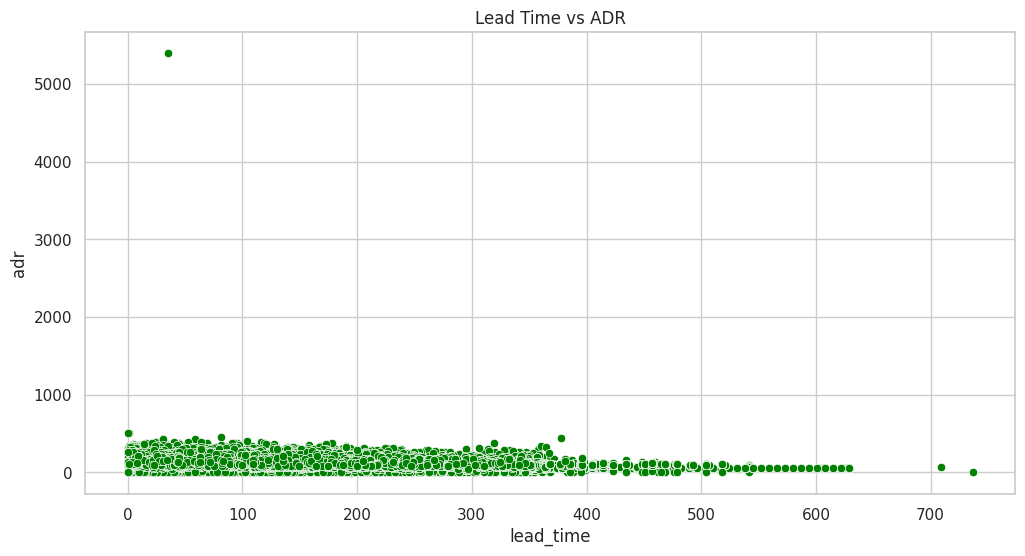

In [93]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='lead_time', y='adr', data=df, color='green')
plt.title("Lead Time vs ADR")
plt.show()

## Weak relationship → pricing not optimized by booking time
## Suggest: early bird discounts

#  Adults vs ADR

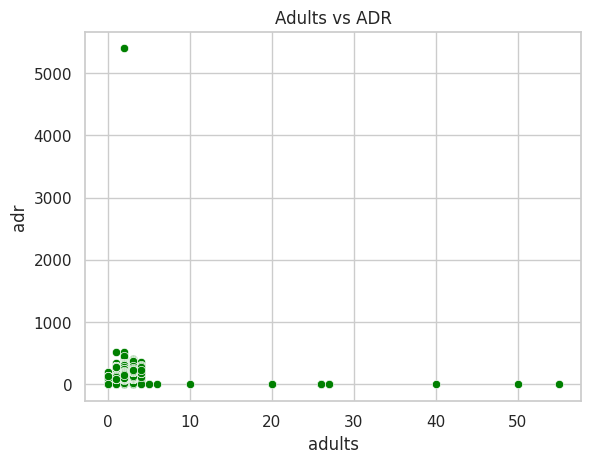

In [94]:
sns.scatterplot(x='adults', y='adr', data=df, color='green')
plt.title("Adults vs ADR")
plt.show()

## More adults → higher ADR
## Target: group/family packages

# Bookings Over Time

In [95]:
monthly = df.groupby('arrival_date_month').size().reset_index(name='count')

fig = px.area(monthly, x='arrival_date_month', y='count',
              color_discrete_sequence=['#6C5CE7'])
fig.show()

## Seasonality visible → peak months
## Optimize pricing & staffing

# Market Segment

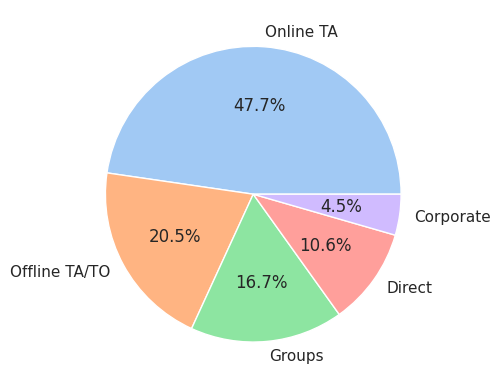

In [96]:
data = df['market_segment'].value_counts().head(5)
plt.pie(data, labels=data.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.show()

## Online TA dominates → dependency risk
## Reduce commission via direct bookings

# Stay Duration

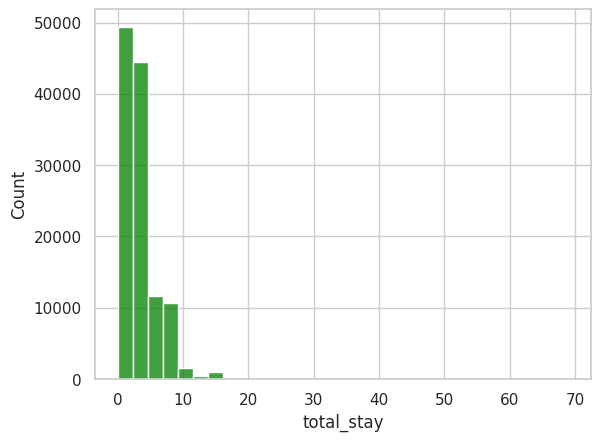

In [97]:
df['total_stay'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

sns.histplot(df['total_stay'], bins=30, color='green')
plt.show()

## Short stays dominate → quick turnover
## Strategy: increase length of stay offers

# Special Requests Distribution

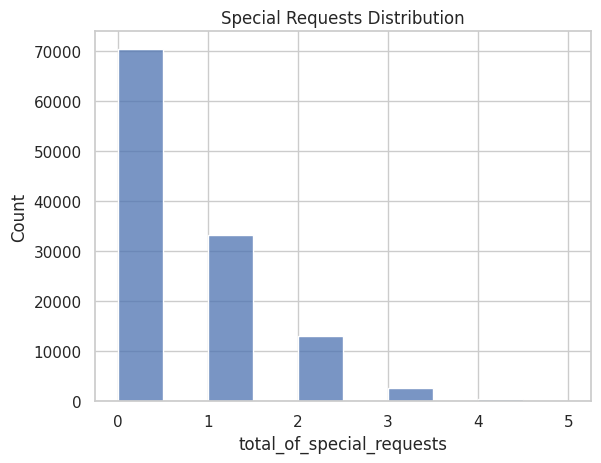

In [98]:
sns.histplot(df['total_of_special_requests'], bins=10,)
plt.title("Special Requests Distribution")
plt.show()

## More requests → higher customer expectations

# Deposit Type

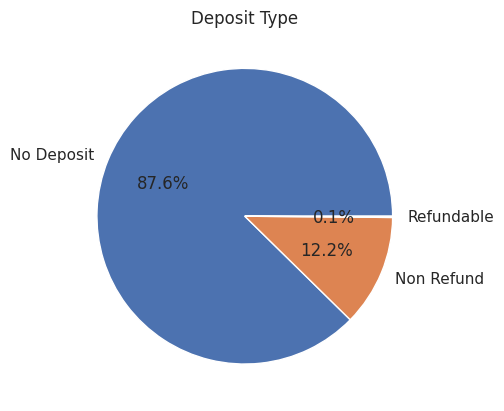

In [99]:
df['deposit_type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Deposit Type")
plt.ylabel("")
plt.show()

## No deposit dominant → higher cancellation risk

# Country-wise Bookings

In [100]:
country = df['country'].value_counts().reset_index()
country.columns = ['country','count']

fig = px.choropleth(country,
                    locations='country',
                    color='count',
                    color_continuous_scale='Viridis')
fig.show()

## Identify top source countries
## Focus geo-targeted marketing

# Waiting List Days

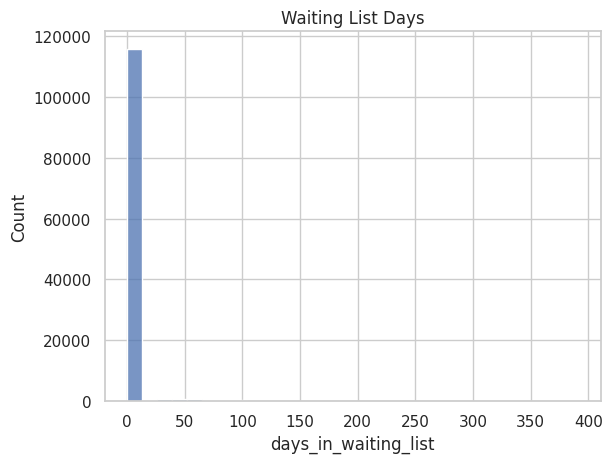

In [101]:
sns.histplot(df['days_in_waiting_list'], bins=30)
plt.title("Waiting List Days")
plt.show()

## Most bookings instant → low backlog pressure

# Parking Requirement

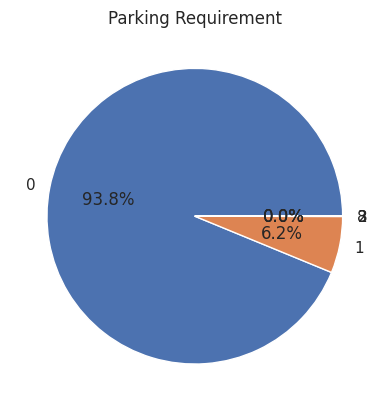

In [102]:
df['required_car_parking_spaces'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Parking Requirement")
plt.ylabel("")
plt.show()

## Low parking demand → urban travelers dominate

# Cancellation Prediction Insight

<Axes: xlabel='is_canceled', ylabel='lead_time'>

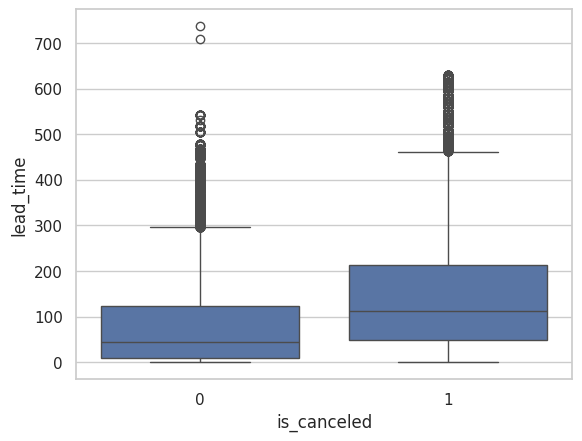

In [103]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)

### Lead time is a strong predictor → build ML model

# Customer Segmentation

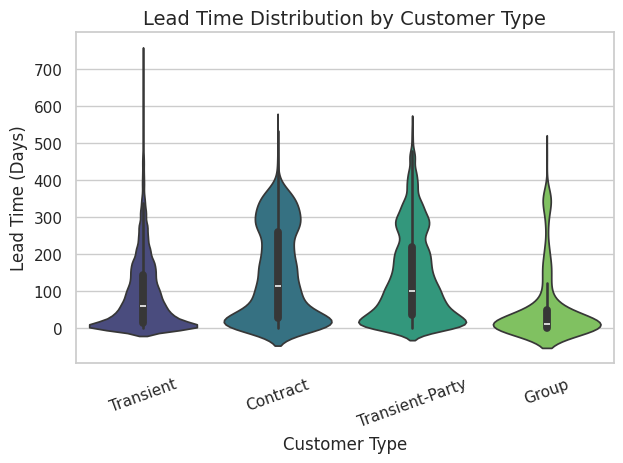

In [104]:


sns.violinplot(
    x='customer_type',
    y='lead_time',
    hue='customer_type',  
    data=df,
    palette='viridis',
    legend=False          
)

plt.title("Lead Time Distribution by Customer Type", fontsize=14)
plt.xlabel("Customer Type", fontsize=12)
plt.ylabel("Lead Time (Days)", fontsize=12)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Business vs leisure behavior difference

# Demand Seasonality Heat Trend

In [105]:
monthly_year = df.groupby(['arrival_date_year','arrival_date_month']).size().reset_index(name='count')

px.area(monthly_year,
        x='arrival_date_month',
        y='count',
        color='arrival_date_year').show()

### Multi-year seasonal comparison

# Final Conclusion & Strategic Insights

###  **High cancellation rates significantly affect revenue stability**, indicating the need for better cancellation policies, deposit strategies, and predictive overbooking models.

###  **City hotels account for the majority of bookings and exhibit higher price variability**, suggesting stronger demand dynamics and greater opportunity for dynamic pricing strategies compared to resort hotels.

###  **Online Travel Agencies (OTAs) are the primary demand drivers**, highlighting heavy reliance on third-party platforms and the need to balance commission costs with direct booking initiatives.

###  **Clear seasonality patterns are observed in booking behavior**, presenting a strong opportunity for **seasonal pricing optimization, demand forecasting, and targeted marketing campaigns**.

###  **Customer segmentation (based on behavior, booking patterns, and demographics) can significantly enhance personalization**, improve retention, and increase overall customer lifetime value.


## Conducted advanced EDA on 119K+ hotel booking records using Python, uncovering key insights on cancellations, pricing strategy, customer segmentation, and seasonal demand using 20+ visualizations.